# Exercise 3.2 #

### Load modules and files ###
* import read_wave from thinkdsp module, that will allow app to read files and do audio specific for that module actions on them 
* create 3 variables and load files into them 

In [1]:
from thinkdsp import read_wave

wave1 = read_wave('Ex3_files/Ex3_sound2.wav')
wave2 = read_wave('Ex3_files/Ex3_sound3.wav')
wave3 = read_wave('Ex3_files/Ex3_sound4.wav')

### Create function that is looking for values in ultrasonic range ###
Ultrasonic range - is frequency that humans can not hear, for average human it is 20 khz, and that is the value this application will be using

In [2]:
# prinst the message if there is sign of significant audio in ultrasonic frequency 
# significant audio I assumed more then 100 amps
# .apms returns different size for different value
# frequency max is 24k for all files, so to get accurate values 
# app needs to map len(.apms)/24000 to get accurate values of amplitude for that frequency
def checkAmpInUltrasonic(wave):
    ampSize = len(wave.amps) #size of amp
    maxFreq = 24000 # to get amp value for 1hz -> .amps[1 * ampSize / maxFreq] 
    minFreq = 20000 # looking for significant audio from that frequency up 
    significantAmp = 100 # set up amp amount that we assue there is hidden audio
    for i in range (int(minFreq * (ampSize/maxFreq)), ampSize,100): #go every 100 for optymalization
        if (wave.amps[i] > significantAmp):
            print('Significant audio found at: ', int(i / (ampSize/maxFreq)))
            return
    print('No significant audio found in ultrasonic frequency')

#### Analyze each audio ####
* make a spectrum to be able to access amplitude values of the sounds
* plot spectogram allows for additional visual analyzis
* run checkAmpInUltrasonic on the file to see if it contains imposible for humans to hear audio message in ultrasonic frequency


#### Testing  wave1 <- Ex3_sound2 ####

No significant audio found in ultrasonic frequency


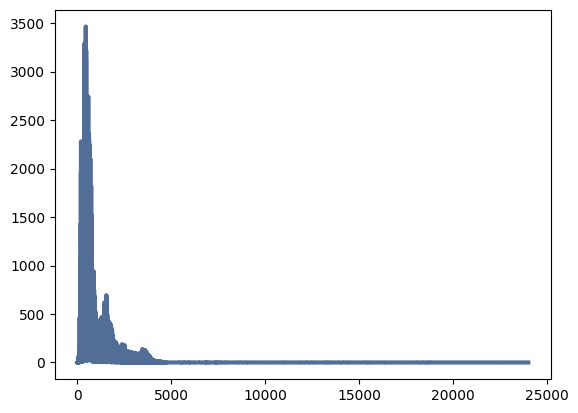

In [3]:
# allows to access amp values of the sound
wave_spectrum1 = wave1.make_spectrum() 

# plot spectogram to also look at the amplitude in frequencys 
wave_spectrum1.plot() 

# check if there is significant audio in ultrasonic frequency
checkAmpInUltrasonic(wave_spectrum1) 

#### Testing  wave2 <- Ex3_sound3 ####

No significant audio found in ultrasonic frequency


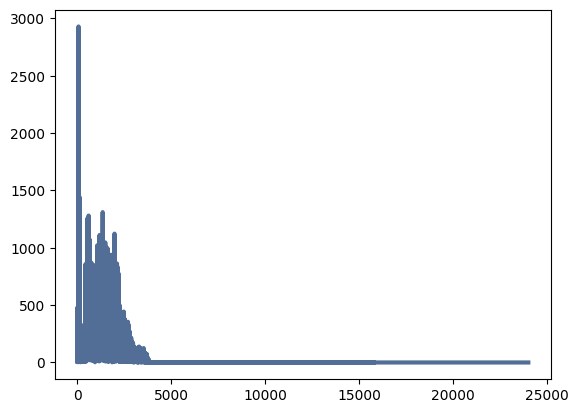

In [4]:

# allows to access amp values of the sound
wave_spectrum2 = wave2.make_spectrum() 

# plot spectogram to also look at the amplitude in frequencys 
wave_spectrum2.plot() 

# check if there is significant audio in ultrasonic frequency
checkAmpInUltrasonic(wave_spectrum2) 


#### Testing  wave3 <- Ex3_sound4 ####

Significant audio found at:  20160


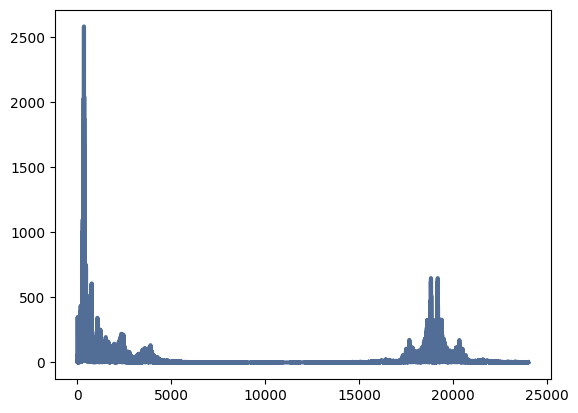

In [5]:
# allows to access amp values of the sound
wave_spectrum3 = wave3.make_spectrum() 

# plot spectogram to also look at the amplitude in frequencys 
wave_spectrum3.plot() 

# check if there is significant audio in ultrasonic frequency
checkAmpInUltrasonic(wave_spectrum3) 

### Analysis result###
When checking every file only Ex3_Sound4 application return positive message that Significant audio found at:  20160. We can also see that visually that first two sounds have amplitude lower than 100 after 5k hz when last sound start to have some significant amplitude changes from around 17k hz to 21k hz. 

Next step of application is to try to move that to hearable for human frequency. 

### Move from ultrasonic range to hearable range ###
* use amplitude modulation to make sound that was in ultrasonic, into frequency that we are able to recognize secret digits
* application will use CosSignal from thinkdsp module

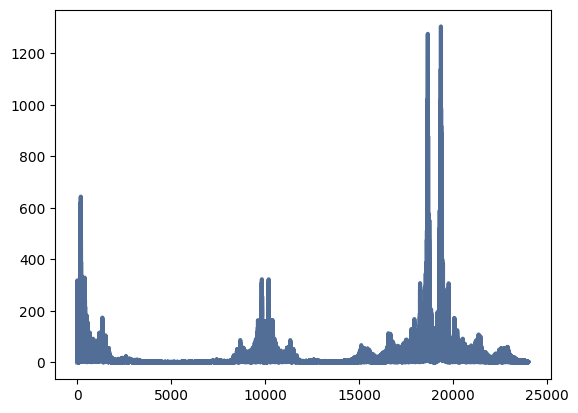

In [7]:
# following code is based of course labs 2.213 Exercise 7: Advanced audio processing with Python
from thinkdsp import CosSignal

# 'move' audio to frequence 
carrier_sig = CosSignal(freq=19000) # after try and error I was able to find good frequency to move 
carrier_wave = carrier_sig.make_wave(duration=wave3.duration, framerate=wave3.framerate)
modulated = wave3 * carrier_wave

# draw spectogram
modulated_spectrum = modulated.make_spectrum()
modulated_spectrum.plot()

#play the code 
modulated.make_audio()


### Result ###
Application :
* sucsesfull detected which audio file (Ex3_sound4.wav) contains hidden message in ultrasonic frequency
* 'Moved' that message from ultrasonic frequency to heareble frequency
* alsow to play secret code: 1891 